In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver # This is kind of memory server whit the help of in memory saver you can implement persistance in your workflow. 
from langchain_groq import ChatGroq

/Users/sanjaymahto/About-AI/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()
llm_model = "llama-3.1-8b-instant"
llm = ChatGroq(
    model=llm_model,
    temperature=0,
)

In [4]:
class JokeState(TypedDict): 
    topic: str 
    joke: str 
    explanation: str 

In [5]:
def generate_joke(state: JokeState): 
    
    prompt = f"Generate joke on the topic {state['topic']}"
    response = llm.invoke(prompt).content
    
    return {
        'joke': response
    }
    
def generate_explanation(state: JokeState): 
    prompt = f"write an explanation for the joke {state['joke']}"
    response = llm.invoke(prompt).content
    
    return {
        'explanation': response
    }

In [6]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)


checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [7]:
config1 = {'configurable': {'thread_id':1}}
workflow.invoke({'topic':'pizza'}, config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.',
 'explanation': 'The joke "Why did the pizza go to the doctor? Because it was feeling a little crusty" is a play on words. It uses a pun to create humor.\n\nIn this joke, "crusty" has a double meaning. \n\n1. A pizza crust is the outer layer of a pizza, which is typically made of bread or dough. So, in this context, "crusty" refers to the pizza\'s physical composition.\n\n2. "Crusty" can also mean irritable or having a rough temperament. For example, if someone is feeling "crusty," they might be grumpy or short-tempered.\n\nThe joke relies on this double meaning to create a pun. The punchline "it was feeling a little crusty" is a clever play on words, as it references both the pizza\'s physical crust and the idea that it\'s feeling irritable. This unexpected twist creates the humor in the joke.'}

In [8]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke "Why did the pizza go to the doctor? Because it was feeling a little crusty" is a play on words. It uses a pun to create humor.\n\nIn this joke, "crusty" has a double meaning. \n\n1. A pizza crust is the outer layer of a pizza, which is typically made of bread or dough. So, in this context, "crusty" refers to the pizza\'s physical composition.\n\n2. "Crusty" can also mean irritable or having a rough temperament. For example, if someone is feeling "crusty," they might be grumpy or short-tempered.\n\nThe joke relies on this double meaning to create a pun. The punchline "it was feeling a little crusty" is a clever play on words, as it references both the pizza\'s physical crust and the idea that it\'s feeling irritable. This unexpected twist creates the humor in the joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoi

In [9]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke "Why did the pizza go to the doctor? Because it was feeling a little crusty" is a play on words. It uses a pun to create humor.\n\nIn this joke, "crusty" has a double meaning. \n\n1. A pizza crust is the outer layer of a pizza, which is typically made of bread or dough. So, in this context, "crusty" refers to the pizza\'s physical composition.\n\n2. "Crusty" can also mean irritable or having a rough temperament. For example, if someone is feeling "crusty," they might be grumpy or short-tempered.\n\nThe joke relies on this double meaning to create a pun. The punchline "it was feeling a little crusty" is a clever play on words, as it references both the pizza\'s physical crust and the idea that it\'s feeling irritable. This unexpected twist creates the humor in the joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpo

In [36]:
workflow.get_state_history(config1)

<generator object Pregel.get_state_history at 0x1185b0b30>

In [40]:

for state in workflow.get_state_history(config1):
    checkpoint_id = state.config['configurable']['checkpoint_id']
    next = state.next
    
print(checkpoint_id)
print(next)

1f0b7bea-7b9c-63b8-bfff-dec5ce1e8476
('__start__',)


In [47]:
mapping = [
    {
        "Next": state.next,
        "thread_id": state.config["configurable"]["thread_id"],
        "checkpoint_id": state.config["configurable"]["checkpoint_id"]
    }
    for state in workflow.get_state_history(config1)
]

print(mapping)


[{'Next': (), 'thread_id': '1', 'checkpoint_id': '1f0b7bea-85d9-674a-8002-0ed6530ce6f1'}, {'Next': ('generate_explanation',), 'thread_id': '1', 'checkpoint_id': '1f0b7bea-8194-693c-8001-ff26677e5149'}, {'Next': ('generate_joke',), 'thread_id': '1', 'checkpoint_id': '1f0b7bea-7bca-69d4-8000-36490af70e6e'}, {'Next': ('__start__',), 'thread_id': '1', 'checkpoint_id': '1f0b7bea-7b9c-63b8-bfff-dec5ce1e8476'}]


In [53]:
for i in mapping: 
    print(i)

{'Next': (), 'thread_id': '1', 'checkpoint_id': '1f0b7bea-85d9-674a-8002-0ed6530ce6f1'}
{'Next': ('generate_explanation',), 'thread_id': '1', 'checkpoint_id': '1f0b7bea-8194-693c-8001-ff26677e5149'}
{'Next': ('generate_joke',), 'thread_id': '1', 'checkpoint_id': '1f0b7bea-7bca-69d4-8000-36490af70e6e'}
{'Next': ('__start__',), 'thread_id': '1', 'checkpoint_id': '1f0b7bea-7b9c-63b8-bfff-dec5ce1e8476'}


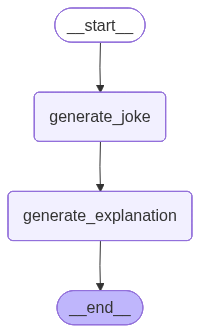

In [49]:
workflow

## Fault Tolerance 

In [10]:
import time 


In [11]:
class CrashState(TypedDict): 
    input: str 
    step1: str 
    step2: str 
    step3: str 
    

In [13]:
# Define step 
def step_1(state: CrashState):
    print("🤫 Step 1 Executed")
    
    return {
        "step1": 'done', 
        'input': state['input']
    }
    
def step_2(state: CrashState): 
    print("⏳ Step 2 hanging... now interrupt")
    time.sleep(30)
    return{
        'step2': 'done'
    }
    
    
def step_3(state: CrashState): 
    print("👍🏻 step 3 executed")
    return {
        'step3': 'done'
    }

In [14]:
# Build the graph 
builder = StateGraph(CrashState)

builder.add_node('step_1', step_1)
builder.add_node('step_2', step_2)
builder.add_node('step_3', step_3)

builder.add_edge(START, 'step_1')
builder.add_edge('step_1', 'step_2')
builder.add_edge('step_2', 'step_3')
builder.add_edge('step_3', END)

checkpointer = InMemorySaver()

graph = builder.compile(checkpointer=checkpointer)

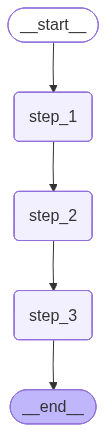

In [15]:
graph

In [16]:
try: 
    print("Running graph: Please manually interrupt during first 2 step")
    graph.invoke(
        {'input': 'start'}, 
        config={'configurable': {'thread_id': 'thread-1'}}
        )
except KeyboardInterrupt:
    print("Kernel manually interrupted (crash simulated)")

Running graph: Please manually interrupt during first 2 step
🤫 Step 1 Executed
⏳ Step 2 hanging... now interrupt
Kernel manually interrupted (crash simulated)


In [17]:
graph.get_state({'configurable': {'thread_id': 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7ea9-1367-6dd0-8001-4749c41ac4ec'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-11-02T12:50:53.498305+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7ea9-1363-6d7a-8000-507804abdafa'}}, tasks=(PregelTask(id='c8762c2b-3bcb-de84-6205-b91ea1d59164', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [19]:
list(graph.get_state_history({'configurable': {'thread_id': 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7ea9-1367-6dd0-8001-4749c41ac4ec'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-11-02T12:50:53.498305+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7ea9-1363-6d7a-8000-507804abdafa'}}, tasks=(PregelTask(id='c8762c2b-3bcb-de84-6205-b91ea1d59164', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7ea9-1363-6d7a-8000-507804abdafa'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-11-02T12:50:53.496652+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch

In [21]:
# Run to show fault-tolerant resume 
final_state = graph.invoke(None, config={'configurable': {'thread_id': 'thread-1'}})
print('final State', final_state)

⏳ Step 2 hanging... now interrupt
👍🏻 step 3 executed
final State {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [22]:
graph.get_state({'configurable': {'thread_id': 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7eb0-a78a-6cc2-8003-34c38ecfee9c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-02T12:54:16.936353+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7eb0-a783-6bde-8002-a359aa367158'}}, tasks=(), interrupts=())

In [23]:
list(graph.get_state_history({'configurable': {'thread_id': 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7eb0-a78a-6cc2-8003-34c38ecfee9c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-02T12:54:16.936353+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7eb0-a783-6bde-8002-a359aa367158'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7eb0-a783-6bde-8002-a359aa367158'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-11-02T12:54:16.933398+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7ea9-1367-6dd0-8001-4749c41ac4ec'}}, tasks=(PregelTask(id='62ae88d3-7fd5-2326

# Time Travel 

In [55]:
# Now what i want is that i want to go back to where i was getting the topic. 
# From this checkpoint i want to play all the execution. 

# You have a checkpoint ID for each checkpoint. 
# 'checkpoint_id': '1f0b7bea-7bca-69d4-8000-36490af70e6e'


workflow.get_state(config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f0b7bea-7bca-69d4-8000-36490af70e6e'}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f0b7bea-7bca-69d4-8000-36490af70e6e'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-11-02T07:36:33.431377+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7bea-7b9c-63b8-bfff-dec5ce1e8476'}}, tasks=(PregelTask(id='32821bb1-a934-9eb9-aa38-1189f535f1b5', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.'}),), interrupts=())

In [56]:
# I want to re-run this checkpoint 
workflow.invoke(None, {'configurable': {'thread_id': '1', 'checkpoint_id': '1f0b7bea-7bca-69d4-8000-36490af70e6e'}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.',
 'explanation': 'The joke "Why did the pizza go to the doctor? Because it was feeling a little crusty" is a play on words. It uses a pun to create humor.\n\nIn this joke, "crusty" has a double meaning. \n\n1. A pizza crust is the outer layer of a pizza, which is typically made of bread or dough. So, in this context, "crusty" refers to the pizza\'s physical composition.\n\n2. "Crusty" can also mean irritable or having a rough temperament. For example, if someone is feeling "crusty," they might be grumpy or short-tempered.\n\nThe joke relies on this double meaning to create a pun. The punchline "it was feeling a little crusty" is a clever play on words, as it references both the pizza\'s physical crust and the idea that it\'s feeling irritable. This unexpected twist creates the humor in the joke.'}

In [57]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke "Why did the pizza go to the doctor? Because it was feeling a little crusty" is a play on words. It uses a pun to create humor.\n\nIn this joke, "crusty" has a double meaning. \n\n1. A pizza crust is the outer layer of a pizza, which is typically made of bread or dough. So, in this context, "crusty" refers to the pizza\'s physical composition.\n\n2. "Crusty" can also mean irritable or having a rough temperament. For example, if someone is feeling "crusty," they might be grumpy or short-tempered.\n\nThe joke relies on this double meaning to create a pun. The punchline "it was feeling a little crusty" is a clever play on words, as it references both the pizza\'s physical crust and the idea that it\'s feeling irritable. This unexpected twist creates the humor in the joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpo